In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
import math
import warnings
from os.path import join
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import tensorflow as tf
from tensorflow import keras
from keras import metrics
import keras_tuner as kt
from tensorflow.keras import initializers


In [2]:
# # Makes working dir the repo - may be needed if have path issues...
# %cd 207_final_project_Alvaro_Jake_Ruchi_Phillip

In [3]:
# Load data
df = pd.read_csv("./data/CA_Weather_Fire_Dataset_1984-2025.csv")
df.head()

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [4]:
counts = df['LAGGED_PRECIPITATION'].value_counts()
percentages_formatted = df['LAGGED_PRECIPITATION'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

# Concatenate counts and percentages into one DataFrame
result_df = pd.DataFrame({'Count': counts, 'Percentage': percentages_formatted})
print(result_df)

                      Count Percentage
LAGGED_PRECIPITATION                  
0.00                  10049      67.0%
0.01                    198       1.3%
0.02                     97       0.6%
0.02                     73       0.5%
0.04                     69       0.5%
...                     ...        ...
0.11                      1       0.0%
0.01                      1       0.0%
0.77                      1       0.0%
1.00                      1       0.0%
0.86                      1       0.0%

[994 rows x 2 columns]


In [5]:
df['LAGGED_PRECIPITATION'].value_counts()

LAGGED_PRECIPITATION
0.00    10049
0.01      198
0.02       97
0.02       73
0.04       69
        ...  
0.11        1
0.01        1
0.77        1
1.00        1
0.86        1
Name: count, Length: 994, dtype: int64

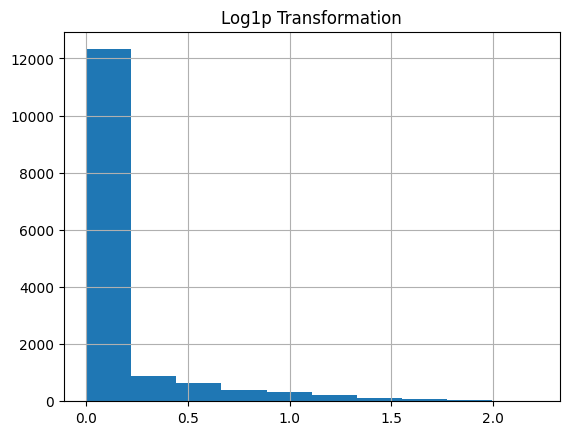

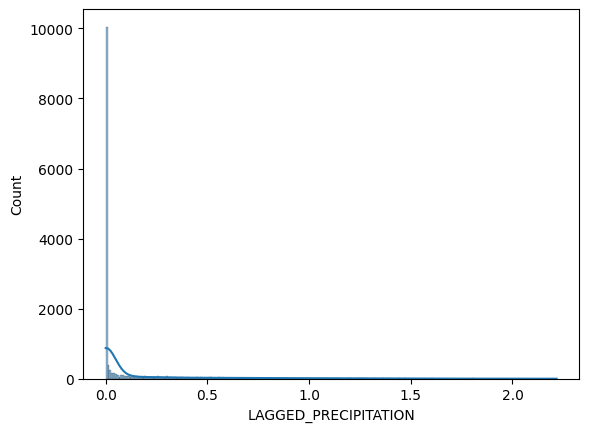

In [6]:
df['LAGGED_PRECIPITATION'].apply(np.log1p).hist()
plt.title("Log1p Transformation")
plt.show()

# Alternatively using Seaborn for better visualization
sns.histplot(np.log1p(df['LAGGED_PRECIPITATION']), kde=True)
plt.show()

This feature requires the data to be in chronological order (counting consecutive dry days resets after each rain event), so it must be computed before shuffling. To address the constraint of not doing time series modeling, we capture the time dependency within a single variable so that each observation can then be treated independently."

In [7]:
# Derive Days Without Rain feature
# True on days with any rain; False on dry days
rain_today = df["PRECIPITATION"] > 0

# creates a running group number that increases by 1 every time a rainy day occurs
# this lets us split the timeline into segments separated by rain
group_id = rain_today.cumsum()


# for dry days (~rain_today), count how many consecutive dry days have occurred within each segment
# resets to 0 after each rain event (because group_id changes on rain days)
df.loc[:, "DAYS_WITHOUT_RAIN"] = (~rain_today).groupby(group_id).cumcount()

In [8]:
# Make column lists

# These cols will likely not inform EDA much. Use this list for easy access
# DATE/YEAR: not helpful in EDA, assuming the underlying climate conditions across years remain relatively constant
# DAY_OF_YEAR: likely same info as Season var
exclude_cols = ['DATE', 'YEAR', 'DAY_OF_YEAR', 'TEMP_RANGE', 'WIND_TEMP_RATIO']

feature_cols = [c for c in df.columns if c not in exclude_cols]
feature_cols.remove('FIRE_START_DAY')
target_col = 'FIRE_START_DAY'
numeric_cols = feature_cols.copy()
numeric_cols.remove('SEASON')
numeric_cols.remove('MONTH')
cols = feature_cols + [target_col]

print(feature_cols)
print(numeric_cols)

['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'MONTH', 'SEASON', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'DAYS_WITHOUT_RAIN']
['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'DAYS_WITHOUT_RAIN']


In [9]:
# Missing values
df.isna().sum()

DATE                      0
PRECIPITATION             1
MAX_TEMP                  1
MIN_TEMP                  1
AVG_WIND_SPEED           12
FIRE_START_DAY            0
YEAR                      0
TEMP_RANGE                1
WIND_TEMP_RATIO          12
MONTH                     0
SEASON                    0
LAGGED_PRECIPITATION      0
LAGGED_AVG_WIND_SPEED     0
DAY_OF_YEAR               0
DAYS_WITHOUT_RAIN         0
dtype: int64

Considering we only have 1- 12 rows of 14988 rows where `avg_wind_speed`, `temp_range` and `wind_temp_ratio` are missing values, we have decided to remove these rows.

Rationale for dropping rows: Since the number of missing values is negligible compared to the size of our dataset, and we are treating each row as an independent observation, we can safely remove the rows containing missing values without affecting our analysis.

In [10]:
# Drop observations with NaN values
df = df.dropna(subset=['AVG_WIND_SPEED', 'MIN_TEMP', 'MAX_TEMP'])
df.isna().sum()

DATE                     0
PRECIPITATION            0
MAX_TEMP                 0
MIN_TEMP                 0
AVG_WIND_SPEED           0
FIRE_START_DAY           0
YEAR                     0
TEMP_RANGE               0
WIND_TEMP_RATIO          0
MONTH                    0
SEASON                   0
LAGGED_PRECIPITATION     0
LAGGED_AVG_WIND_SPEED    0
DAY_OF_YEAR              0
DAYS_WITHOUT_RAIN        0
dtype: int64

#### We will consider each row as I.I.D and not consider any time dependency between each row. We are not including the following columns: `date`, `year`, `day_of_year` in our analysis to avoid any temporal dependency between the rows, thus allowing each row to be unique.

In [131]:

warnings.filterwarnings('ignore')
# Outlier Identification + Treatment
# Options for treatment: 
#   - winsorization (set lower/upper outliers to 1%/99% -iles)
#   - remove if small percentage of the data, do nothing if not?

for f in numeric_cols:
    print(f)
    # Identify outliers using 1.5*IQR
    q1_pctile, q3_pctile = df[f].quantile(0.25), df[f].quantile(0.75)
    iqr = q3_pctile - q1_pctile
    lower, upper = q1_pctile - (1.5*iqr), q3_pctile + (1.5*iqr)
    low_outliers, high_outliers = df.loc[(df[f] < lower), :], df.loc[(df[f] > upper), :]
    pct_outliers = (len(low_outliers) + len(high_outliers))/len(df)
    print(f"pct of points outliers: {pct_outliers:.2%}")
    # Winsorize outliers
    original = df[f].copy()
    df[f] = df[f].clip(lower=df[f].quantile(0.01),
                         upper=df[f].quantile(0.99))
    changed = (original != df[f]).sum()
    pct_changed = changed / len(df)
    print(f"pct data changed by winsorization: {changed}/{len(df)} = {pct_changed:.2%}")
    print("=============")

PRECIPITATION
pct of points outliers: 9.22%
pct data changed by winsorization: 149/14976 = 0.99%
MAX_TEMP
pct of points outliers: 1.08%
pct data changed by winsorization: 237/14976 = 1.58%
MIN_TEMP
pct of points outliers: 0.01%
pct data changed by winsorization: 266/14976 = 1.78%
AVG_WIND_SPEED
pct of points outliers: 3.20%
pct data changed by winsorization: 262/14976 = 1.75%
LAGGED_PRECIPITATION
pct of points outliers: 20.47%
pct data changed by winsorization: 148/14976 = 0.99%
LAGGED_AVG_WIND_SPEED
pct of points outliers: 1.23%
pct data changed by winsorization: 299/14976 = 2.00%
DAYS_WITHOUT_RAIN
pct of points outliers: 7.39%
pct data changed by winsorization: 144/14976 = 0.96%


In [11]:
# One-hot encode season and month
# first by converting them to string type
df['SEASON'] = df['SEASON'].astype(str)
df['MONTH'] = df['MONTH'].astype(str)

df = pd.get_dummies(df, columns=['SEASON', 'MONTH'], prefix=['SEASON', 'MONTH'])
print(df.columns)

Index(['DATE', 'PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
       'FIRE_START_DAY', 'YEAR', 'TEMP_RANGE', 'WIND_TEMP_RATIO',
       'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'DAY_OF_YEAR',
       'DAYS_WITHOUT_RAIN', 'SEASON_Fall', 'SEASON_Spring', 'SEASON_Summer',
       'SEASON_Winter', 'MONTH_1', 'MONTH_10', 'MONTH_11', 'MONTH_12',
       'MONTH_2', 'MONTH_3', 'MONTH_4', 'MONTH_5', 'MONTH_6', 'MONTH_7',
       'MONTH_8', 'MONTH_9'],
      dtype='object')


In [12]:
df = df.drop(columns=exclude_cols)
df.columns

Index(['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
       'FIRE_START_DAY', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED',
       'DAYS_WITHOUT_RAIN', 'SEASON_Fall', 'SEASON_Spring', 'SEASON_Summer',
       'SEASON_Winter', 'MONTH_1', 'MONTH_10', 'MONTH_11', 'MONTH_12',
       'MONTH_2', 'MONTH_3', 'MONTH_4', 'MONTH_5', 'MONTH_6', 'MONTH_7',
       'MONTH_8', 'MONTH_9'],
      dtype='object')

In [13]:
# converting all df columns to lowercase
df.columns = df.columns.str.lower()

In [135]:
df.describe()

,precipitation,max_temp,min_temp,avg_wind_speed,lagged_precipitation,lagged_avg_wind_speed,days_without_rain
count,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000
mean,0.026779,70.519164,56.504708,7.418707,0.213976,7.430643,29.805355
std,0.126273,7.114970,6.679011,2.027665,0.564975,1.360638,36.491032
min,0.000000,56.000000,41.750000,3.580000,0.000000,4.248571,0.000000
25%,0.000000,65.000000,51.000000,6.040000,0.000000,6.518571,4.000000
50%,0.000000,70.000000,57.000000,7.160000,0.000000,7.478571,14.000000
75%,0.000000,75.000000,62.000000,8.500000,0.060000,8.278571,42.000000
max,0.930000,91.000000,70.000000,14.990000,3.250000,10.874286,156.000000


# Data Shuffling and Splitting


In [14]:
# 1. creating and printing list of indices mapping to df's rows
indices = df.index.tolist()
indices

np.random.seed(0)
# 2. Shuffling indices and calling array shuffled_indices. 
shuffled_indices = np.random.permutation(indices)

In [15]:
#Printing this array
shuffled_indices

array([ 3657,  7156, 14516, ...,  9848, 10802,  2732], shape=(14976,))

In [16]:
# 3. change the ordering of the dataset based on the order in the shuffled_indices array
df = df.reindex(shuffled_indices)

In [17]:
# printing head(5) for top 5 rows to confirm they match new index in shuffled_indices
df.head(5)

,precipitation,max_temp,min_temp,avg_wind_speed,fire_start_day,lagged_precipitation,lagged_avg_wind_speed,days_without_rain,season_fall,season_spring,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
3657,0.0,66.0,53.0,5.82,False,0.0,5.974286,10,False,False,...,False,False,False,False,False,False,False,False,False,False
7156,0.0,78.0,61.0,7.83,True,0.0,8.597143,8,False,False,...,False,False,False,False,False,False,False,False,True,False
14516,0.0,70.0,65.0,6.49,False,0.0,6.614286,12,True,False,...,False,False,False,False,False,False,False,False,False,True
1948,0.0,72.0,55.0,6.04,False,0.0,7.702857,38,False,True,...,False,False,False,False,False,True,False,False,False,False
12141,0.0,75.0,54.0,5.82,False,0.0,9.490000,7,False,True,...,False,False,False,True,False,False,False,False,False,False


### Defining Outcome and Features

In [20]:
# first outcome dataframe with 'FIRE_START_DAY' and named Y. printing Y
Y = df[['fire_start_day']]
Y

,fire_start_day
3657,False
7156,True
14516,False
1948,False
12141,False
...,...
13126,False
3264,False
9848,False
10802,True


In [21]:
# feature dataframe called X with features of interest: 
temp = df.copy()
temp = temp.drop(columns=['fire_start_day'])
X = temp

### Data Splits

In [22]:
# 1. first splitting test set since train_test_split method only splits 2 sets a time
X_temporary, X_test, Y_temporary, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1234)

In [23]:
# second splitting test set since train_test_split method only splits 2 sets a time
X_train, X_val, Y_train, Y_val = train_test_split(X_temporary, Y_temporary, test_size=0.25, random_state=1234)

In [24]:
# 2. printing shape of each array:X_train, X_val, X_test, Y_train, Y_val, Y_test;
print("shape of X_train:", X_train.shape)
print("shape of X_val:", X_val.shape)
print("shape of X_test:", X_test.shape)
print("shape of Y_train:", Y_train.shape)
print("shape of Y_val:", Y_val.shape)
print("shape of Y_test:", Y_test.shape)

shape of X_train: (8985, 23)
shape of X_val: (2995, 23)
shape of X_test: (2996, 23)
shape of Y_train: (8985, 1)
shape of Y_val: (2995, 1)
shape of Y_test: (2996, 1)


In [25]:
X_train.describe()

,precipitation,max_temp,min_temp,avg_wind_speed,lagged_precipitation,lagged_avg_wind_speed,days_without_rain
count,8985.000000,8985.000000,8985.000000,8985.00000,8985.000000,8985.000000,8985.000000
mean,0.032237,70.598776,56.564830,7.44845,0.222162,7.445269,30.169839
std,0.186746,7.208081,6.724433,2.13074,0.638710,1.388670,37.242788
min,0.000000,50.000000,35.000000,2.01000,0.000000,3.227143,0.000000
25%,0.000000,65.000000,52.000000,6.04000,0.000000,6.520000,4.000000
50%,0.000000,70.000000,57.000000,7.38000,0.000000,7.507143,14.000000
75%,0.000000,75.000000,62.000000,8.50000,0.060000,8.308571,42.000000
max,4.530000,105.000000,77.000000,22.59000,8.120000,13.325714,222.000000


In [26]:
X_train.dtypes

precipitation            float64
max_temp                 float64
min_temp                 float64
avg_wind_speed           float64
lagged_precipitation     float64
lagged_avg_wind_speed    float64
days_without_rain          int64
season_fall                 bool
season_spring               bool
season_summer               bool
season_winter               bool
month_1                     bool
month_10                    bool
month_11                    bool
month_12                    bool
month_2                     bool
month_3                     bool
month_4                     bool
month_5                     bool
month_6                     bool
month_7                     bool
month_8                     bool
month_9                     bool
dtype: object

In [147]:
X_train.columns

Index(['precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
       'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain',
       'season_fall', 'season_spring', 'season_summer', 'season_winter',
       'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9'],
      dtype='object')

# ------------ MOVING THIS BELOW DATASPLIT----------------####

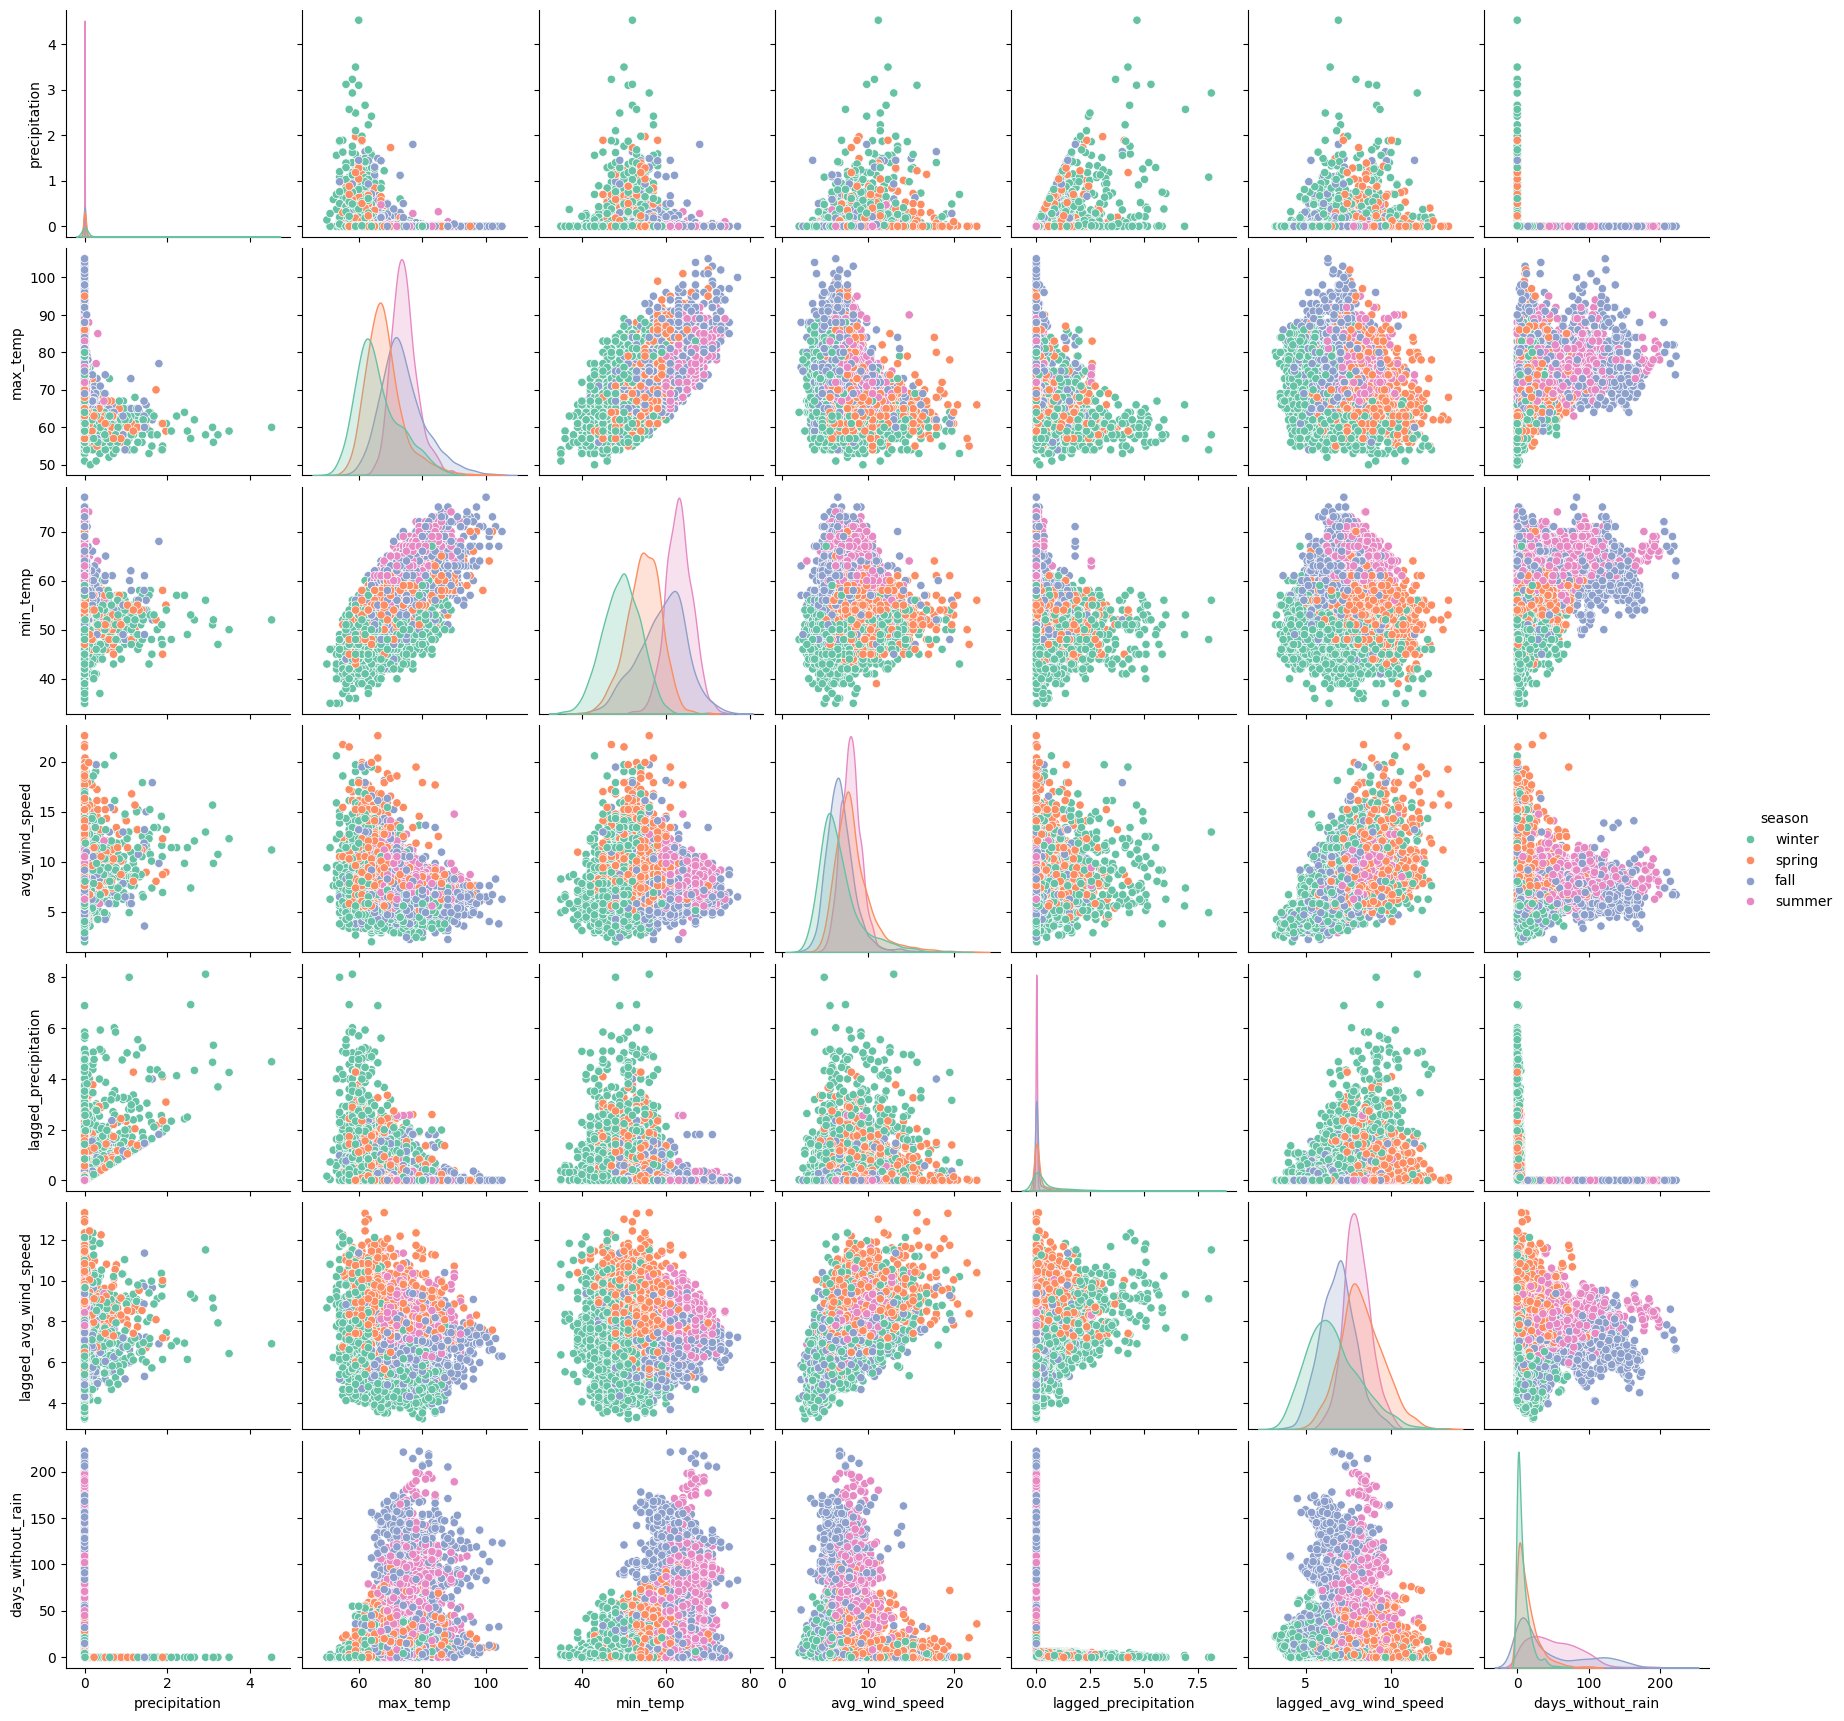

In [27]:
# creating scatter plot with season as color hue
# Selecting only the numeric/continuous variables
numeric_cols = [
    'precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
    'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain']


season_cols = ['season_fall', 'season_spring', 'season_summer', 'season_winter']

X_train['season'] = X_train[season_cols].idxmax(axis=1)
X_train['season'] = X_train['season'].str.replace('season_', '')
sns.pairplot(
    X_train,
    vars=numeric_cols,
    hue='season',
    palette='Set2',
    diag_kind='kde'
)

plt.show()

In [28]:
X_train.columns

Index(['precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
       'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain',
       'season_fall', 'season_spring', 'season_summer', 'season_winter',
       'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'season'],
      dtype='object')

In [29]:
X_train = X_train.drop(columns='season')
X_train.columns

Index(['precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
       'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain',
       'season_fall', 'season_spring', 'season_summer', 'season_winter',
       'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9'],
      dtype='object')

In [30]:
num_cols = ['precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
       'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain']

# Investigate collinearities
# For numeric variables, 
#    - calculate Pearson corr for measure of linear correlation
#    - calculate Spearman/Kendall correlation for measure of similarly ranked values in both series
corr_pearson = X_train[num_cols].corr(method='pearson')
corr_spearman = X_train[num_cols].corr(method='spearman')
corr_kendall = X_train[num_cols].corr(method='kendall')

In [31]:
corr_pearson
#corr_spearman
#corr_kendall

,precipitation,max_temp,min_temp,avg_wind_speed,lagged_precipitation,lagged_avg_wind_speed,days_without_rain
precipitation,1.000000,-0.227500,-0.108490,0.216305,0.483356,0.042625,-0.139857
max_temp,-0.227500,1.000000,0.634231,-0.173268,-0.337941,-0.083348,0.386598
min_temp,-0.108490,0.634231,1.000000,0.121108,-0.301708,0.099228,0.514132
avg_wind_speed,0.216305,-0.173268,0.121108,1.000000,0.109647,0.597915,-0.010244
lagged_precipitation,0.483356,-0.337941,-0.301708,0.109647,1.000000,0.166518,-0.267523
lagged_avg_wind_speed,0.042625,-0.083348,0.099228,0.597915,0.166518,1.000000,0.006104
days_without_rain,-0.139857,0.386598,0.514132,-0.010244,-0.267523,0.006104,1.000000


In [32]:
# Feature-to-target correlations

# calculate Pearson correlation for all numeric features + target variable
corr_pearson_full = pd.concat([X_train[num_cols], Y_train], axis=1).corr(method='pearson') 
corr_with_target = corr_pearson_full['fire_start_day'].drop('fire_start_day') # extract just the correlations of each feature with the target variable, excluding the self-correlation of target with itself

# Display results sorted by correlation strength
print("CORRELATION OF FEATURES WITH fire_start_day (Target Variable)")
print("="*60)
print(corr_with_target.sort_values(ascending=False)) # sort by strength of correlation with target variable
print()

# Identify strongest predictors
print("KEY INSIGHTS:")
print("="*60)
print(f"Strongest positive predictor: {corr_with_target.idxmax()} with correlation: r = {corr_with_target.max():.4f}")
print()
print(f"Strongest negative predictor: {corr_with_target.idxmin()} with correlation: r = {corr_with_target.min():.4f}")
print()

# Categorize correlations by strength
print("CORRELATION STRENGTH BREAKDOWN:")
print("="*60)

# Define thresholds for categorizing correlation strength based on common conventions
strong_pos = corr_with_target[corr_with_target > 0.3]
moderate_pos = corr_with_target[(corr_with_target > 0.1) & (corr_with_target <= 0.3)]
weak_pos = corr_with_target[(corr_with_target > 0) & (corr_with_target <= 0.1)]

# For negative correlations, we can use the same thresholds but in the negative direction
weak_neg = corr_with_target[(corr_with_target < 0) & (corr_with_target >= -0.1)]
moderate_neg = corr_with_target[(corr_with_target < -0.1) & (corr_with_target >= -0.3)]
strong_neg = corr_with_target[corr_with_target < -0.3]

# Print out the number of features in each category along with their names and correlation values for strong and moderate categories
if len(strong_pos) > 0:
    print(f"Strong positive (r > 0.3): {len(strong_pos)} features")
    for feat in strong_pos.index:
        print(f"  • {feat}: r = {strong_pos[feat]:.4f}")
    print()
if len(moderate_pos) > 0:
    print(f"Moderate positive (0.1 < r ≤ 0.3): {len(moderate_pos)} features")
    for feat in moderate_pos.index:
        print(f"  • {feat}: r = {moderate_pos[feat]:.4f}")
    print()
if len(weak_pos) > 0:
    print(f"Weak positive (0 < r ≤ 0.1): {len(weak_pos)} features")
    for feat in weak_pos.index:
        print(f"  • {feat}: r = {weak_pos[feat]:.4f}")
    print()
if len(weak_neg) > 0:
    print(f"Weak negative (-0.1 ≤ r < 0): {len(weak_neg)} features")
    for feat in weak_neg.index:
        print(f"  • {feat}: r = {weak_neg[feat]:.4f}")
    print()
if len(moderate_neg) > 0:
    print(f"Moderate negative (-0.3 ≤ r < -0.1): {len(moderate_neg)} features")
    for feat in moderate_neg.index:
        print(f"  • {feat}: r = {moderate_neg[feat]:.4f}")
    print()
if len(strong_neg) > 0:
    print(f"Strong negative (r < -0.3): {len(strong_neg)} features")
    for feat in strong_neg.index:
        print(f"  • {feat}: r = {strong_neg[feat]:.4f}")
    print()

CORRELATION OF FEATURES WITH fire_start_day (Target Variable)
min_temp                 0.465952
max_temp                 0.362707
days_without_rain        0.310327
lagged_avg_wind_speed    0.074812
avg_wind_speed           0.023340
precipitation           -0.111653
lagged_precipitation    -0.211570
Name: fire_start_day, dtype: float64

KEY INSIGHTS:
Strongest positive predictor: min_temp with correlation: r = 0.4660

Strongest negative predictor: lagged_precipitation with correlation: r = -0.2116

CORRELATION STRENGTH BREAKDOWN:
Strong positive (r > 0.3): 3 features
  • max_temp: r = 0.3627
  • min_temp: r = 0.4660
  • days_without_rain: r = 0.3103

Weak positive (0 < r ≤ 0.1): 2 features
  • avg_wind_speed: r = 0.0233
  • lagged_avg_wind_speed: r = 0.0748

Moderate negative (-0.3 ≤ r < -0.1): 2 features
  • precipitation: r = -0.1117
  • lagged_precipitation: r = -0.2116



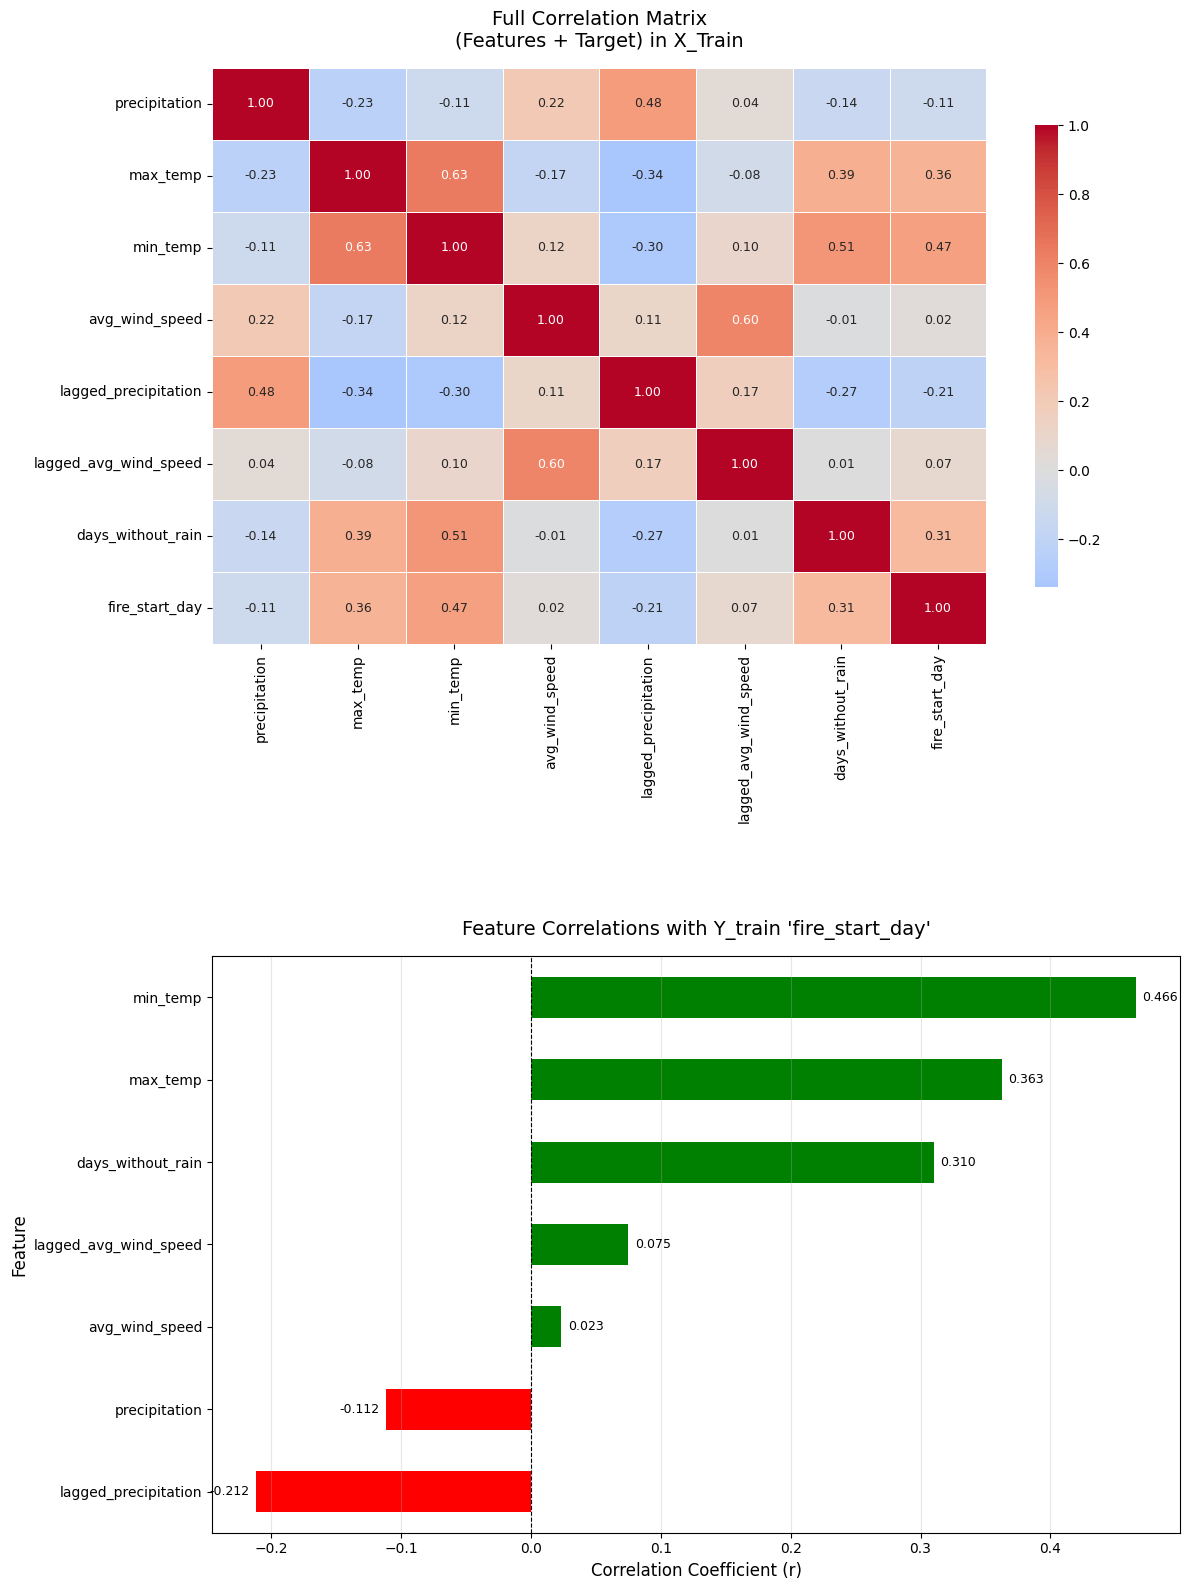

In [33]:
# Create figure with two subplots - STACKED VERTICALLY
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Top: Full correlation matrix (features + target)
sns.heatmap(corr_pearson_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=False,
            linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9},
            ax=axes[0])
axes[0].set_title('Full Correlation Matrix\n(Features + Target) in X_Train', fontsize=14, pad=15)

# Bottom: Bar plot of feature-target correlations
corr_sorted = corr_with_target.sort_values()
colors = ['red' if x < 0 else 'green' for x in corr_sorted]
corr_sorted.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_xlabel('Correlation Coefficient (r)', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].set_title('Feature Correlations with Y_train \'fire_start_day\'', fontsize=14, pad=15)
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(axis='x', alpha=0.3)

# Add value labels to bars for clarity
for i, (idx, val) in enumerate(corr_sorted.items()):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005, i, 
                f'{val:.3f}', va='center', 
                ha='left' if val >= 0 else 'right', fontsize=9)

plt.subplots_adjust(hspace=0.9)  # ADD THIS LINE - controls vertical space
plt.tight_layout(h_pad=7.0)
plt.show()

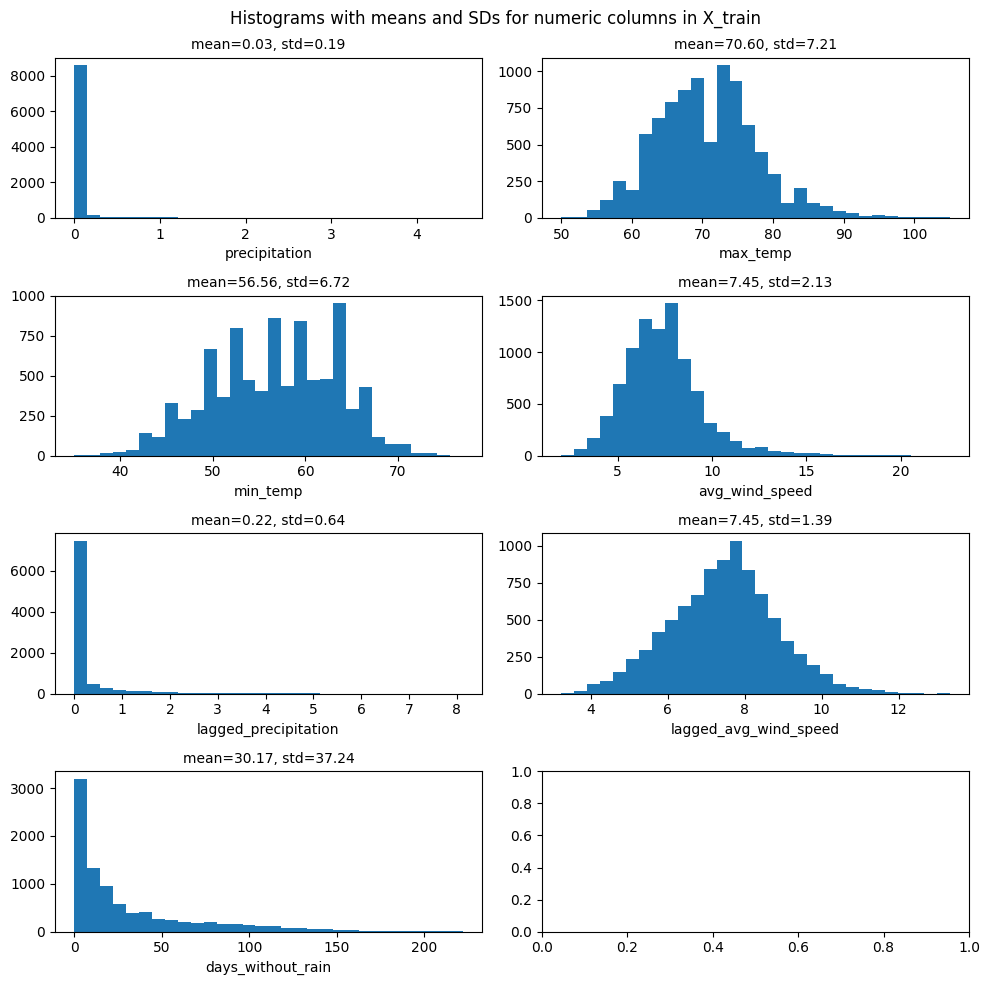

In [34]:

# Distributions
rows = math.ceil(len(num_cols)/2)
fig, axs = plt.subplots(rows, 2, figsize=(10,10))
fig.suptitle('Histograms with means and SDs for numeric columns in X_train')
for i, f in enumerate(num_cols):
    row = i // 2
    col = i % 2
    axs[row, col].hist(X_train[f], bins=30)
    axs[row, col].set_xlabel(f'{f}')
    mean, std = X_train[f].mean(), X_train[f].std()
    axs[row, col].set_title(f"mean={mean:.2f}, std={std:.2f}", fontsize=10)
plt.tight_layout()
plt.show()

In [35]:
# Finding descriptive statistics to ascertain if any variables need to be log transformed
df.describe()

,precipitation,max_temp,min_temp,avg_wind_speed,lagged_precipitation,lagged_avg_wind_speed,days_without_rain
count,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000
mean,0.032338,70.540932,56.499666,7.435098,0.226366,7.434007,30.008213
std,0.179607,7.261989,6.766055,2.129985,0.648934,1.384969,37.292797
min,0.000000,50.000000,33.000000,1.790000,0.000000,3.227143,0.000000
25%,0.000000,65.000000,51.000000,6.040000,0.000000,6.518571,4.000000
50%,0.000000,70.000000,57.000000,7.160000,0.000000,7.478571,14.000000
75%,0.000000,75.000000,62.000000,8.500000,0.060000,8.278571,42.000000
max,4.530000,106.000000,77.000000,26.170000,8.180000,13.932857,225.000000


In [36]:

print(df.dtypes)

precipitation            float64
max_temp                 float64
min_temp                 float64
avg_wind_speed           float64
fire_start_day              bool
lagged_precipitation     float64
lagged_avg_wind_speed    float64
days_without_rain          int64
season_fall                 bool
season_spring               bool
season_summer               bool
season_winter               bool
month_1                     bool
month_10                    bool
month_11                    bool
month_12                    bool
month_2                     bool
month_3                     bool
month_4                     bool
month_5                     bool
month_6                     bool
month_7                     bool
month_8                     bool
month_9                     bool
dtype: object


# Standardization starts here

### Standardization only on X_train data

In [37]:
X_train.columns

Index(['precipitation', 'max_temp', 'min_temp', 'avg_wind_speed',
       'lagged_precipitation', 'lagged_avg_wind_speed', 'days_without_rain',
       'season_fall', 'season_spring', 'season_summer', 'season_winter',
       'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9'],
      dtype='object')

In [39]:
numeric_cols_lower = [i.lower() for i in numeric_cols]

# Creating copies to avoid any warning later
X_train_std = X_train.copy()
X_val_std = X_val.copy()
X_test_std = X_test.copy()

# initializing the scaler
scaler = StandardScaler()


# fitting on train and transforming train, val and test to avoid data leakage
X_train_std[numeric_cols_lower] = scaler.fit_transform(X_train[numeric_cols_lower])
X_val_std[numeric_cols_lower] = scaler.transform(X_val[numeric_cols_lower])
X_test_std[numeric_cols_lower] = scaler.transform(X_test[numeric_cols_lower])

In [40]:
X_train_std.head()

,precipitation,max_temp,min_temp,avg_wind_speed,lagged_precipitation,lagged_avg_wind_speed,days_without_rain,season_fall,season_spring,season_summer,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
8767,-0.172635,0.610630,0.213438,-0.764307,-0.347849,-1.127234,-0.461050,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4149,-0.172635,-0.638038,-0.232721,0.493542,-0.347849,0.185503,-0.165675,False,True,False,...,False,False,False,False,False,True,False,False,False,False
8502,-0.172635,-0.221816,-0.530160,1.859340,-0.347849,-0.112846,-0.380493,False,True,False,...,False,False,False,False,True,False,False,False,False,False
6298,-0.172635,-0.638038,-0.084001,0.282336,-0.347849,-0.391649,-0.541607,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4400,-0.172635,-0.776779,-0.976320,-0.135383,0.012272,0.231799,-0.756426,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Confirming that Y values are showing up as 1 and 0 for the binary classification

In [41]:
# Make copies of the original dataset for binary classification task.
Y_train = np.copy(Y_train)
Y_test = np.copy(Y_test)

# reclassifying if Y_train from boolean to integer (1/0)
Y_train = (Y_train.astype(int))
Y_test = (Y_test.astype(int))

print(np.unique(Y_train))
print(np.unique(Y_test))

[0 1]
[0 1]


### Checking for class imbalance in Y_train

In [42]:
# counting training set and percentages
# unique values and their raw counts
labels, counts = np.unique(Y_train, return_counts=True)

# calculating percentage
percentage = (counts/len(Y_train)) *100

for label, count, percent in zip(labels, counts, percentage):
    print(f"Class {label}: {count} samples ({percent}%)")

Class 0: 6015 samples (66.9449081803005%)
Class 1: 2970 samples (33.0550918196995%)


### Baseline Model (Alvaro)

In [43]:
# baseline model
values, counts = np.unique(Y_train, return_counts=True)
baseline_model = values[counts.argmax()]

# baseline probability = majority class proportion
p = counts.max() / counts.sum()

# binary cross-entropy loss
def binary_cross_entropy(y_true, p):
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# baseline model accuracies for train and val data
baseline_train_acc = np.mean(Y_train == baseline_model)
baseline_val_acc = np.mean(Y_val == baseline_model)
train_loss = binary_cross_entropy(Y_train, p)
val_loss = binary_cross_entropy(Y_val, p)

# print majority class and accuracies
print(f"Majority class: {baseline_model}")
print(f"Baseline train accuracy: {baseline_train_acc:.4f} | loss: {train_loss:.4f}")
print(f"Baseline val accuracy:   {baseline_val_acc:.4f} | loss: {val_loss:.4f}")

Majority class: 0
Baseline train accuracy: 0.6694 | loss: 0.8737
Baseline val accuracy:   0.6658 | loss: 0.8711


### Building Logistic Regression (Ruchi)

In [44]:
def build_model(hp):
  """Build a TF linear regression model using Keras.

  Args:
    #TODO NEED TO ADD THIS
  Returns:
    model: A tf.keras model (graph).
  """
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  num_features = X_train_std.shape[1]
    
  # providing a range of learning rates for the later search history and tuner next
  hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001, 0.00001])
  hp_batch_size = hp.Choice('batch_size', values=[16, 32, 64])
    
  # Build a model using keras.Sequential. We want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim = 1 as we want 1 layer
      input_shape=(num_features,),
      use_bias=True,               # use a bias (intercept) param
      activation='sigmoid',
      kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),  
      bias_initializer=tf.zeros,    # initialize bias to 0
  ))
 

  # Compile the model with binary_accuracy for graphing
  model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer =tf.keras.optimizers.SGD(learning_rate=hp_learning_rate),
        metrics=['binary_accuracy']
  )
    
  return model

In [47]:
# initializing the tuner where function of build_model function is being passed
# it will build and tune the model through the learning rates
tuner = kt.Hyperband(
    hypermodel=build_model, # passing that function from above telling tuner how to build the model_tf
    objective='val_binary_accuracy', # matches the metric in build_model
    max_epochs=100,
    factor=3,
    directory='tuning_dir',
    project_name='lr_batch_tuner',
    overwrite=True
)
# callback to stop training early after reaching a certain value for the validation loss.
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# tuner search with max
tuner.search(X_train_std, Y_train, validation_data=(X_val_std, Y_val), callbacks = [stop_early]) 

# provides the best optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 12 Complete [00h 00m 02s]
val_binary_accuracy: 0.3939899802207947

Best val_binary_accuracy So Far: 0.7696160078048706
Total elapsed time: 00h 00m 20s


In [49]:
print(best_hps.values)

{'learning_rate': 0.01, 'batch_size': 64, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 4, 'tuner/round': 0}


In [50]:
## Finding the best epoch 
# Now using the best_hps to build temporary model with the optimal hyperparameters identified above and train model
best_batch = best_hps.get('batch_size')

# building model with best settings
model_tf = tuner.hypermodel.build(best_hps)

# retraining on higher epochs to find peak performance
history = model_tf.fit(X_train_std, Y_train, 
                         epochs=100, 
                         batch_size=best_batch, #using tuned batch_size from best_hps
                         validation_data=(X_val_std, Y_val), 
                         class_weight={0: 1, 1: 2}, # Adjusting for the 67/33 split
                         verbose = 0
                        )


c:\Users\pjdun\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
# Show learned model with weights and biases from 
w = model_tf.layers[0].get_weights()[0]  # the weights matrix
b = model_tf.layers[0].get_weights()[1]  # the bias vector

print('First Bias:', b[0])
print('First 4 Weights', w[:4].flatten())

# 3. loss at the final epoch
train_loss = history.history['loss'][-1]
train_binary_accuracy = history.history['binary_accuracy'][-1]
val_loss = history.history['val_loss'][-1]
val_binary_accuracy = history.history['val_binary_accuracy'][-1]

print('Final train loss:', train_loss)
print('Final validation loss:', val_loss)
print('Final train_accuracy:', train_binary_accuracy)
print("Final_val_accuracy:", val_binary_accuracy)

First Bias: -0.341708
First 4 Weights [-0.20435591  0.38596654  0.3714884  -0.08462625]
Final train loss: 0.6715322732925415
Final validation loss: 0.5040374398231506
Final train_accuracy: 0.7530328035354614
Final_val_accuracy: 0.7585976719856262


In [52]:
# 4. percentage difference between the losses observed on the training and validation datasets
percentage_diff = ((train_loss - val_loss)/train_loss)*100
print(" percentage difference between the losses observed on the training and validation datasets:",percentage_diff )

 percentage difference between the losses observed on the training and validation datasets: 24.94218671697773


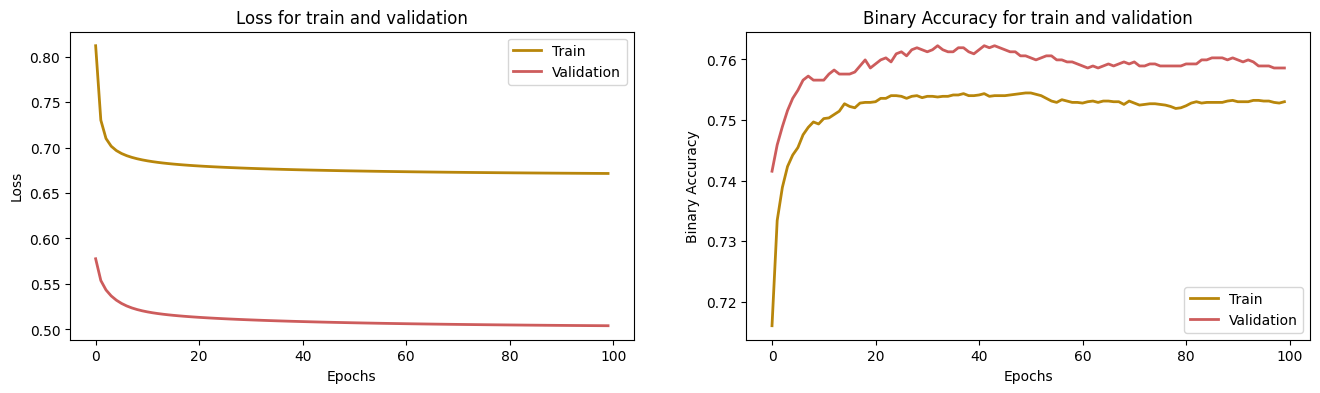

In [53]:
# grab history
history = history.history

# plot loss for train and validation
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history['loss'], lw=2, color='darkgoldenrod')
plt.plot(history['val_loss'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_ylabel('Loss')
ax.set_title('Loss for train and validation');

# plot accuracy for train and validation
ax = fig.add_subplot(1, 2, 2)
plt.plot(history['binary_accuracy'], lw=2, color='darkgoldenrod')
plt.plot(history['val_binary_accuracy'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_ylabel('Binary Accuracy')
ax.set_title('Binary Accuracy for train and validation');

### Model evaluation and generalization

In [54]:
### print accuracy for test based on running the trained model on the test data 
# (the model outputs probabilities)
# getting predicted probabilities using model_tf tuned above
y_train_prob = model_tf.predict(x = X_train_std)
y_test_prob = model_tf.predict(x=X_test_std)

train_labels = (y_train_prob > 0.5).astype(int)
test_labels = (y_test_prob > 0.5).astype(int)

# printing accuracies
train_accuracy = np.mean(train_labels == Y_train)
test_accuracy  = np.mean(test_labels == Y_test)

print("Aggregate train accuracy:", train_accuracy)
print("Aggregate test accuracy:", test_accuracy)
print("Gap between aggregate test and train accuracy", test_accuracy - train_accuracy)



281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step
Aggregate train accuracy: 0.752253756260434
Aggregate test accuracy: 0.7593457943925234
Gap between aggregate test and train accuracy 0.007092038132089362


In [55]:
## evaluating the model
train_results = model_tf.evaluate(X_train_std, Y_train, verbose=0)
test_results = model_tf.evaluate(X_test_std, Y_test, verbose=0)

print("Train loss:", train_results[0])
print("Test loss:", test_results[0])
print("Gap between train and test loss:", test_results[0] - train_results[0])

Train loss: 0.5085952281951904
Test loss: 0.4966050088405609
Gap between train and test loss: -0.011990219354629517


### Metrics

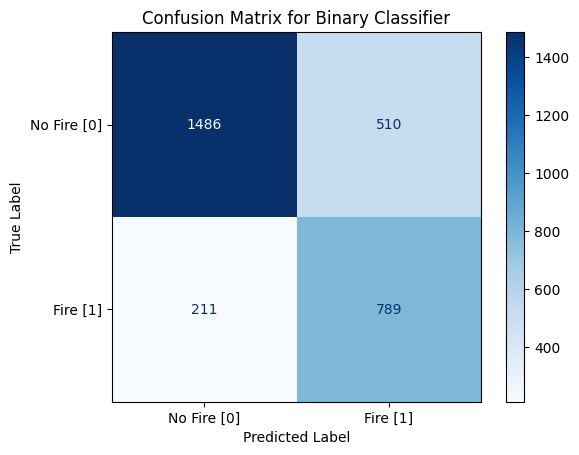

In [56]:
# set predicted label based on threshold of 0.5
y_test_pred = (y_test_prob > 0.5).astype(int)

# displaying the Confusion Matrix on the test data 
disp = ConfusionMatrixDisplay.from_predictions(Y_test, y_test_pred, cmap=plt.cm.Blues,
                                              display_labels=["No Fire [0]", "Fire [1]"])

disp.ax_.set_title("Confusion Matrix for Binary Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Show the confusion matrix plot
plt.show()

In [57]:
# the precision and recall
from sklearn.metrics import classification_report
print(classification_report(
    y_true = Y_test, # this is the actual ground truth in 0s and 1s
    y_pred = y_test_pred,  # labels predicted by model_tf
    target_names=['No Fire', 'Fire']))

              precision    recall  f1-score   support

     No Fire       0.88      0.74      0.80      1996
        Fire       0.61      0.79      0.69      1000

    accuracy                           0.76      2996
   macro avg       0.74      0.77      0.75      2996
weighted avg       0.79      0.76      0.77      2996



### Learnings from Logistic model: Considering logistic regression model is giving accuracy of 0.76 or 76% which is better than the baseline guessing of 67% (no fire), so 9% better. The model is catching 0.79 or 79% of all fires (fire recall), which we would like to explore as getting better with our next two models. The fire precision (60%) means that 40% are false alarms, when it was not a fire. Again, we would like to make these better with are more advanced models.

### Visualizing AOC -- Not sure we need this, but adding it in

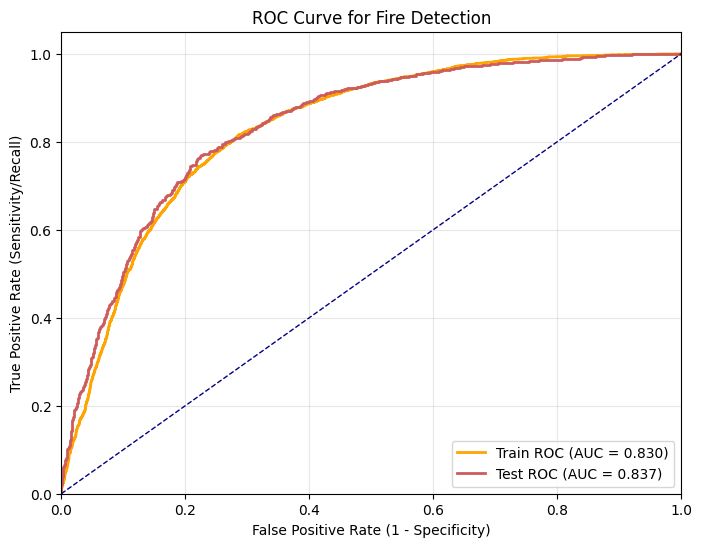

In [58]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve data
fpr_train, tpr_train, _ = roc_curve(Y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(Y_test, y_test_prob)

# AUC (Area Under Curve) calculation
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# plotting the AUC curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.3f})', color='orange', lw=2)
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.3f})', color='indianred', lw=2)

# this creates the reference line for a "random" model
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve for Fire Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### Interpretation of AUC curve metrics
Given the AUC score is above 0.80, the model is doing really well to differentiate between "Fire" and "No Fire" days. The train and test curves are close to each other showing the logistic regression model is not overfitting. The point furthest away from the diagonal line  of random guessing is close to 0.7 (7 of 10 Fire days) for True Positive Rate, but 0.2 on the False Positive rate (2 of 10 false alarms). That is minimizing False Positive (false alarms for "Fire" day) while showing a relatively high True Positive rate (real "Fire" day)

**Notes/Questions** (OLD NOTES)
- How do we handle time dependency?

Logistic regression/gradient descent allows for dependence between observations. Will need to consider for train test split (ie use the more recent observations as the test set)

- What to do with time-related features for logistic regression?

Some seem relevant - ie season. But don't think about autocorrelations in observations re: the outcome variable. Think about every sample as independent and then for the time-related features, include them if you thinkn they inform risk for the observation on that given day

- What to do about collinearities? Do we need to handle?

Even if have a perfectly collinear feature, thats still mechanically fine for gradient descent. Gradient descent can handle anything mechanically.

But for the best performance, get rid of collinear features or combine them (add or multiply)

For fitting a logistic regression model, one COULD try every combo of features, fit model, and see which has the best AIC/BIC, but that may be beyond scope. 

## Model 2: Random Forest Classifier (Phil)

Random Forest is an ensemble method that builds multiple independent decision trees on
bootstrapped subsets of the training data, then aggregates their predictions by majority vote.
Unlike logistic regression, Random Forest captures non-linear relationships and feature
interactions without requiring feature scaling — raw features are used directly.

**Key design decisions:**
- `class_weight='balanced'` to address the ~67/33 no-fire/fire class imbalance
- Hyperparameter tuning by manually iterating over candidate values of `n_estimators`
  and `max_depth` - the two key RF hyperparameters - and selecting the combination
  with the highest F1-score on the validation set
- Raw (unstandardized) features used - tree-based models are invariant to feature scale
- Evaluated on the held-out test set; results compared directly to logistic regression baseline

**Imports added:** `RandomForestClassifier` from sklearn.ensemble

In [ ]:
# added by Phil 3-21-2026
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

def wildfire_rf_tune_and_train(X_train, Y_train, X_val, Y_val):
    """
    wildfire_rf_tune_and_train: Tune and train a Random Forest classifier by
    manually iterating over a parameter grid and selecting the combination
    with the highest F1-score on the validation set.

    Parameters:
    X_train : pandas DataFrame - training features (unstandardized; RF is scale-invariant)
    Y_train : numpy array      - binary training labels (0 = no fire, 1 = fire), shape (n, 1)
    X_val   : pandas DataFrame - validation features
    Y_val   : numpy array      - binary validation labels, shape (n, 1)

    Returns:
    sklearn.ensemble.RandomForestClassifier: best_model_rf - fitted model with best parameters
    """
    # Define parameter grid to search
    n_estimators_options = [100, 200, 250, 300]
    max_depth_options     = [3, 4, 5, 6, 10, 20, 50, None]

    print("Hyperparameter Grid Search (Manual):")
    print("="*35)
    print(f"n_estimators candidates : {n_estimators_options}")
    print(f"max_depth candidates    : {max_depth_options}")
    print()

    # Iterate over all parameter combinations and evaluate on validation set
    print("Evaluating combinations:")
    print("="*35)

    best_f1        = -1
    best_params    = {}
    best_model_rf  = None

    for n_est in n_estimators_options:  # iterate over n_estimators options
        for depth in max_depth_options: # iterate over max_depth options

            # Initialize and train candidate model
            candidate = RandomForestClassifier( # initialize RF with current hyperparameters
                n_estimators=n_est,
                max_depth=depth,
                class_weight='balanced',
                n_jobs=-1,
                random_state=1234,
            )
            candidate.fit(X_train, Y_train.ravel()) # train on training set

            # Evaluate F1 on validation set (fire class)
            y_val_pred = candidate.predict(X_val) # get predicted labels for validation set
            report     = classification_report(   # compute precision, recall, f1 for each class, where a class is considered "Fire" if label=1 and "No Fire" if label=0
                Y_val.values.ravel(), y_val_pred, # true labels and predicted labels for validation set
                target_names=['No Fire', 'Fire'],
                output_dict=True,
                zero_division=0,
            )
            val_f1 = report['Fire']['f1-score'] # extract F1-score for "Fire" class (label=1) from classification report

            print(f"  n_estimators={n_est:>3}, max_depth={str(depth):>4}  ->  Val F1: {val_f1:.4f}") # print results for current combination of n_estimators and max_depth, showing the validation F1-score for the "Fire" class (label=1)

            # Track best combination by validation F1 as the for loops iterate through all combinations of n_estimators and max_depth
            if val_f1 > best_f1:
                best_f1       = val_f1
                best_params   = {'n_estimators': n_est, 'max_depth': depth}
                best_model_rf = candidate

    # Report best parameters found
    print()
    print("Best Hyperparameters Found:")
    print("="*35)
    print(f"n_estimators : {best_params['n_estimators']}")
    print(f"max_depth    : {best_params['max_depth']}")
    print(f"Best Val F1  : {best_f1:.4f}")
    print()
    print()
    
    return best_model_rf

# Execute wildfire_rf_tune_and_train
best_model_rf = wildfire_rf_tune_and_train(X_train, Y_train, X_val, Y_val)

Hyperparameter Grid Search (Manual):
n_estimators candidates : [100, 200, 250, 300]
max_depth candidates    : [3, 4, 5, 6, 10, 20, 50, None]

Evaluating combinations:
  n_estimators=100, max_depth=   3  ->  Val F1: 0.6838
  n_estimators=100, max_depth=   4  ->  Val F1: 0.6869
  n_estimators=100, max_depth=   5  ->  Val F1: 0.6874
  n_estimators=100, max_depth=   6  ->  Val F1: 0.6848
  n_estimators=100, max_depth=  10  ->  Val F1: 0.6823
  n_estimators=100, max_depth=  20  ->  Val F1: 0.6496
  n_estimators=100, max_depth=  50  ->  Val F1: 0.6249
  n_estimators=100, max_depth=None  ->  Val F1: 0.6249
  n_estimators=200, max_depth=   3  ->  Val F1: 0.6840
  n_estimators=200, max_depth=   4  ->  Val F1: 0.6853
  n_estimators=200, max_depth=   5  ->  Val F1: 0.6859
  n_estimators=200, max_depth=   6  ->  Val F1: 0.6863
  n_estimators=200, max_depth=  10  ->  Val F1: 0.6829
  n_estimators=200, max_depth=  20  ->  Val F1: 0.6537
  n_estimators=200, max_depth=  50  ->  Val F1: 0.6274
  n_esti

Random Forest - Test Set Confusion Matrix:


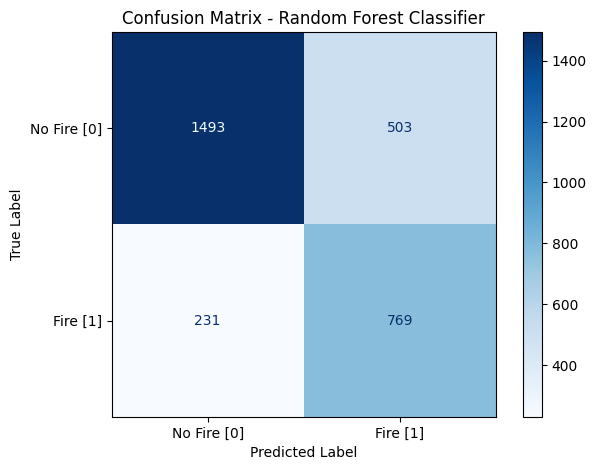


Random Forest - Classification Report:
              precision    recall  f1-score   support

     No Fire       0.87      0.75      0.80      1996
        Fire       0.60      0.77      0.68      1000

    accuracy                           0.76      2996
   macro avg       0.74      0.76      0.74      2996
weighted avg       0.78      0.76      0.76      2996



In [62]:
def wildfire_rf_evaluate(model_rf, X_test, Y_test):
    """
    wildfire_rf_evaluate: Generate confusion matrix and classification report
    for the trained Random Forest on the test set.

    Parameters:
    model_rf : sklearn.ensemble.RandomForestClassifier - trained RF model
    X_test   : pandas DataFrame - test features
    Y_test   : numpy array      - binary test labels (0 = no fire, 1 = fire), shape (n, 1)

    Returns:
    numpy array: y_test_pred_rf - predicted binary labels for test set
    """
    # Generate predictions on test set
    y_test_pred_rf = model_rf.predict(X_test)

    # Display confusion matrix (layout matches logistic regression section)
    print("Random Forest - Test Set Confusion Matrix:")
    print("="*35)
    disp = ConfusionMatrixDisplay.from_predictions(  # generate confusion matrix plot using true labels and predicted labels for test set
        Y_test.ravel(),                              # true labels for test set, flattened to 1D array
        y_test_pred_rf,                              # predicted labels for test set from Random Forest model
        cmap=plt.cm.Blues,
        display_labels=["No Fire [0]", "Fire [1]"],
    )
    disp.ax_.set_title("Confusion Matrix - Random Forest Classifier")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    print()

    # Print classification report
    print("Random Forest - Classification Report:")
    print("="*35)
    print(classification_report( # generate classification report using true labels and predicted labels for test set
        y_true=Y_test.ravel(),   # true labels for test set, flattened to 1D array
        y_pred=y_test_pred_rf,   # predicted labels for test set from Random Forest model
        target_names=['No Fire', 'Fire'],
    ))

    return y_test_pred_rf

# Execute wildfire_rf_evaluate
y_test_pred_rf = wildfire_rf_evaluate(best_model_rf, X_test, Y_test) # get predicted labels for test set from evaluating best Random Forest model

**Interpreting the Random Forest Confusion Matrix and Classification Report:**  

* The model is confusing some no-fire days for fire days (503 false alarms) and some fire days for no-fire days (231 missed fires).

* The model is reasonably good at catching real fires (77% recall) but raises too many false alarms (40% of its fire predictions are wrong - ie. it only got 60% right). It performs better on no-fire days simply because there are more of them in the data.

* Overall accuracy (F1-score) of 76% represents a meaningful improvement over the majority class baseline of 68% (always predicting no fire), demonstrating the model has learned genuine signal from the weather features.

* The trade-off between false alarms (false positives) and missed fires (false negatives) is inherent to this type of problem. In a wildfire risk context, a missed fire is generally more costly than a false alarm, which argues for prioritizing recall over precision.

* The model performs better on the No Fire class (F1=0.80) than the Fire class (F1=0.68). This is expected given the 67/33 class imbalance in the data, even with class_weight='balanced' applied.

* The seasonal subgroup analysis below explains why aggregate performance is moderate. The model's ability to detect fires varies dramatically by season, which the overall confusion matrix obscures.

Top 15 Feature Importances (Mean Decrease in Impurity):
   1. min_temp                     0.2949
   2. max_temp                     0.1602
   3. season_summer                0.1330
   4. days_without_rain            0.1115
   5. lagged_precipitation         0.1012
   6. season_winter                0.0496
   7. lagged_avg_wind_speed        0.0226
   8. month_7                      0.0161
   9. precipitation                0.0140
  10. month_9                      0.0121
  11. month_1                      0.0105
  12. month_5                      0.0095
  13. month_8                      0.0091
  14. avg_wind_speed               0.0085
  15. season_fall                  0.0066



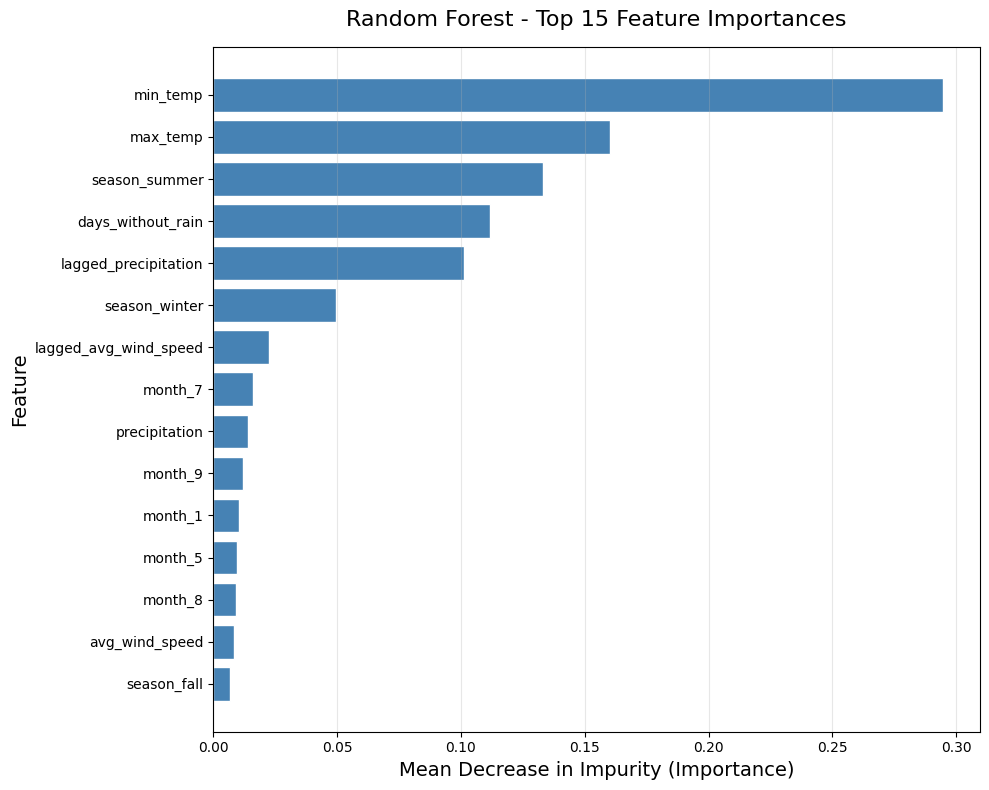

In [66]:
def wildfire_rf_feature_importance(model_rf, feature_names, top_n=15):
    """
    wildfire_rf_feature_importance: Plot the top N most important features
    from the trained Random Forest using mean decrease in impurity.

    Parameters:
    model_rf      : sklearn.ensemble.RandomForestClassifier - trained RF model
    feature_names : list - column names from the feature DataFrame
    top_n         : int  - number of top features to display (default 15)

    Returns:
    pandas DataFrame: importance_df - all features ranked by importance score
    """
    # Extract importances and build ranked DataFrame
    importances = model_rf.feature_importances_
    importance_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances,
    })
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

    # Print ranked table for top N features
    print(f"Top {top_n} Feature Importances (Mean Decrease in Impurity):")
    print("="*35)
    for i, row in importance_df.head(top_n).iterrows():
        print(f"  {i+1:>2}. {row['feature']:<28} {row['importance']:.4f}")
    print()

    # Plot horizontal bar chart
    top_features = importance_df.head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(
        y=top_features['feature'][::-1],
        width=top_features['importance'][::-1],
        color='steelblue',
        edgecolor='white',
    )
    plt.xlabel('Mean Decrease in Impurity (Importance)', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.title(f'Random Forest - Top {top_n} Feature Importances', fontsize=16, pad=15)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return importance_df


# Execute wildfire_rf_feature_importance
importance_df = wildfire_rf_feature_importance(best_model_rf, feature_names=list(X_train.columns))

Random Forest - ROC AUC Score:
AUC: 0.8314



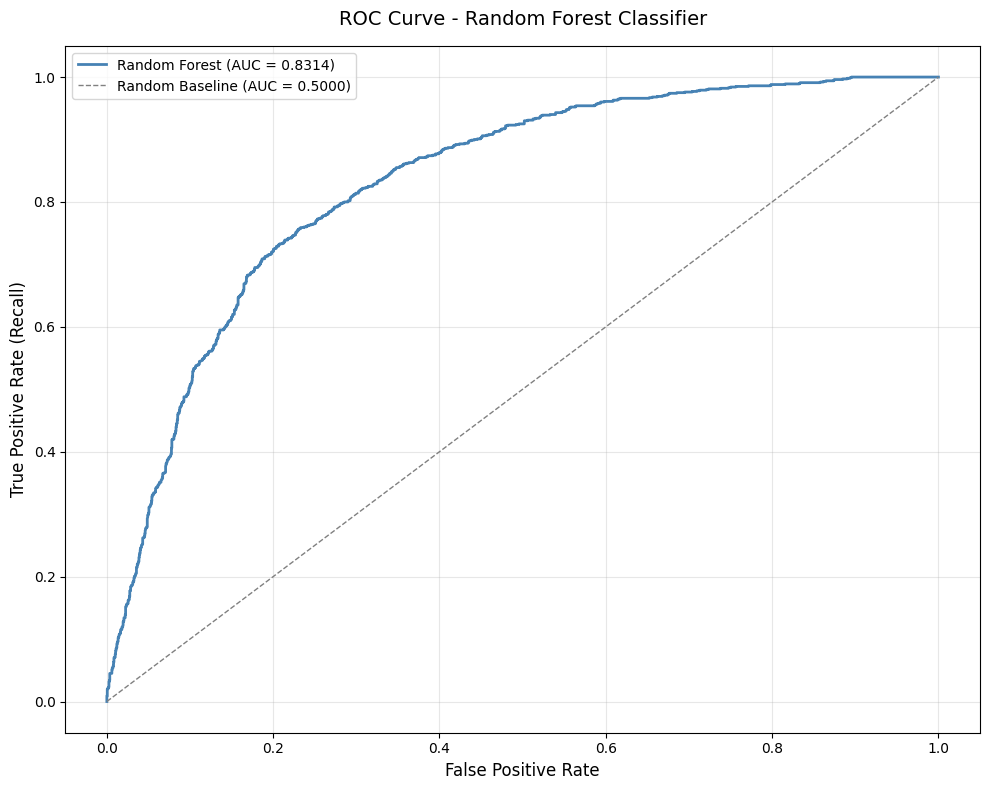

In [64]:
def wildfire_rf_roc_curve(model_rf, X_test, Y_test):
    """
    wildfire_rf_roc_curve: Plot the ROC curve and compute AUC for the
    trained Random Forest on the test set.

    Parameters:
    model_rf : sklearn.ensemble.RandomForestClassifier - trained RF model
    X_test   : pandas DataFrame - test features
    Y_test   : numpy array      - binary test labels (0 = no fire, 1 = fire), shape (n, 1)

    Returns:
    float: roc_auc_rf - area under the ROC curve
    """
    # Get predicted probabilities for positive class (fire = 1)
    y_test_prob = model_rf.predict_proba(X_test)[:, 1] # get predicted probabilities for the positive class (fire=1) from the Random Forest model for the test set

    # Compute FPR, TPR, and AUC score 
    # AUC (Area Under the Curve): single summary score (0-1) of overall model discrimination ability; higher is better; 0.5 = random guessing, 1.0 = perfect classifier
    # FPR (False Positive Rate):  proportion of actual no-fire days incorrectly predicted as fire (false alarms)
    # TPR (True Positive Rate):   proportion of actual fire days correctly predicted as fire (recall)

    fpr, tpr, thresholds = roc_curve(Y_test.ravel(), y_test_prob) # compute false positive rate, true positive rate, and thresholds for ROC curve using true labels and predicted probabilities for test set
    roc_auc_rf = auc(fpr, tpr) # compute area under the ROC curve using false positive rate and true positive rate

    print("Random Forest - ROC AUC Score:")
    print("="*35)
    print(f"AUC: {roc_auc_rf:.4f}")
    print()

    # Plot ROC curve with random baseline for reference
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--',
             label='Random Baseline (AUC = 0.5000)')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve - Random Forest Classifier', fontsize=14, pad=15)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return roc_auc_rf

# Execute wildfire_rf_roc_curve
roc_auc_rf = wildfire_rf_roc_curve(best_model_rf, X_test, Y_test)

Random Forest - Seasonal Subgroup Performance:
Season          N   Fire%    Acc   FireRec   FirePrec   FireF1
-----------------------------------
Fall          710   33.0%  0.621     0.709      0.452    0.552
Spring        720   22.9%  0.772     0.358      0.504    0.418
Summer        791   69.2%  0.689     0.995      0.691    0.816
Winter        775    7.0%  0.929     0.000      0.000    0.000



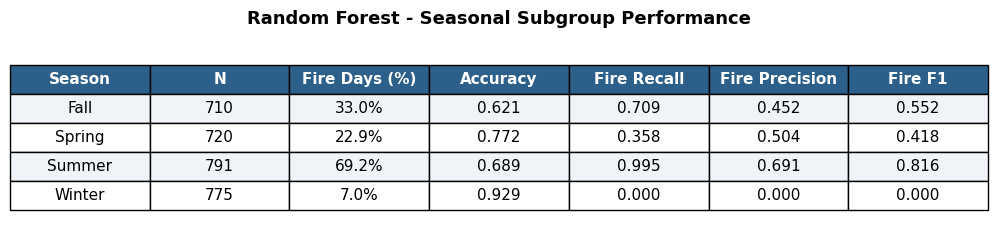

In [72]:
def wildfire_rf_seasonal_subgroup(model_rf, X_test, Y_test):
    """
    wildfire_rf_seasonal_subgroup: Evaluate Random Forest performance broken
    out by season subgroup on the test set.

    Parameters:
    model_rf : sklearn.ensemble.RandomForestClassifier - trained RF model
    X_test   : pandas DataFrame - test features (must contain season dummy columns)
    Y_test   : numpy array      - binary test labels (0 = no fire, 1 = fire), shape (n, 1)

    Returns:
    pandas DataFrame: subgroup_df - per-season accuracy, fire recall, fire precision, fire F1
    """
    # Generate predictions on full test set
    y_pred = model_rf.predict(X_test)
    y_true = Y_test.ravel()

    # Map each test row to its season using one-hot dummy columns
    season_cols   = ['season_fall', 'season_spring', 'season_summer', 'season_winter']
    season_labels = ['Fall', 'Spring', 'Summer', 'Winter']

    print("Random Forest - Seasonal Subgroup Performance:")
    print("="*35)
    print(f"{'Season':<10} {'N':>6} {'Fire%':>7} {'Acc':>6} {'FireRec':>9} {'FirePrec':>10} {'FireF1':>8}")
    print("-"*35)

    # Iterate over each season and compute metrics
    results = []
    for col, label in zip(season_cols, season_labels):
        mask     = X_test[col].values.astype(bool)
        y_true_s = y_true[mask]
        y_pred_s = y_pred[mask]
        n        = len(y_true_s)

        if n == 0:
            continue

        acc      = (y_true_s == y_pred_s).mean()
        fire_pct = y_true_s.mean()

        report   = classification_report(
            y_true_s, y_pred_s,
            target_names=['No Fire', 'Fire'],
            output_dict=True,
            zero_division=0,
        )
        fire_rec  = report['Fire']['recall']
        fire_prec = report['Fire']['precision']
        fire_f1   = report['Fire']['f1-score']

        print(f"{label:<10} {n:>6} {fire_pct:>7.1%} {acc:>6.3f} {fire_rec:>9.3f} {fire_prec:>10.3f} {fire_f1:>8.3f}")

        results.append({
            'season':         label,
            'n':              n,
            'fire_pct':       fire_pct,
            'accuracy':       acc,
            'fire_recall':    fire_rec,
            'fire_precision': fire_prec,
            'fire_f1':        fire_f1,
        })

    # Build dataframe FIRST before table code references it
    subgroup_df = pd.DataFrame(results)

    # Display seasonal results as formatted table
    display_df = pd.DataFrame({
        'Season':         subgroup_df['season'],
        'N':              subgroup_df['n'].astype(int),
        'Fire Days (%)':  subgroup_df['fire_pct'].apply(lambda x: f"{x:.1%}"),
        'Accuracy':       subgroup_df['accuracy'].apply(lambda x: f"{x:.3f}"),
        'Fire Recall':    subgroup_df['fire_recall'].apply(lambda x: f"{x:.3f}"),
        'Fire Precision': subgroup_df['fire_precision'].apply(lambda x: f"{x:.3f}"),
        'Fire F1':        subgroup_df['fire_f1'].apply(lambda x: f"{x:.3f}"),
    })

    print()
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.axis('off')
    table = ax.table(cellText=display_df.values, colLabels=display_df.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    for col in range(len(display_df.columns)):
        table[0, col].set_facecolor('#2c5f8a')
        table[0, col].set_text_props(color='white', fontweight='bold')
    for row in range(1, len(display_df) + 1):
        for col in range(len(display_df.columns)):
            table[row, col].set_facecolor('#f0f4f8' if row % 2 else '#ffffff')
    plt.title('Random Forest - Seasonal Subgroup Performance',
              fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    return subgroup_df

# Execute wildfire_rf_seasonal_subgroup
subgroup_df = wildfire_rf_seasonal_subgroup(best_model_rf, X_test, Y_test)

